# Notebook 2: Coherent States: The Quantum Description of Laser Light

## What are we exploring?

**Coherent states** $|\alpha\rangle$ are the quantum states produced by idealized
single-mode lasers. They are created by applying the **displacement operator** to
the vacuum:
$$|\alpha\rangle = \hat{D}(\alpha)|0\rangle, \quad
\hat{D}(\alpha) = \exp(\alpha\hat{a}^\dagger - \alpha^*\hat{a})$$

Coherent states are eigenstates of the annihilation operator: $\hat{a}|\alpha\rangle = \alpha|\alpha\rangle$.

## Why coherent states are special

Coherent states bridge the quantum-classical divide. They are the **most classical**
quantum states: minimum uncertainty, Poissonian photon statistics, and positive
Wigner functions. At high photon numbers ($|\alpha|^2 \gg 1$), they become
indistinguishable from classical electromagnetic waves.

## Operator and representation note

The displacement operator $\hat{D}(\alpha)$ is a unitary Heisenberg-Weyl group
element acting on bosonic Fock space. It implements phase-space translations and
provides a concrete example of a group action on quantum states.

## Conventions used in this notebook

- Natural units are used for the oscillator algebra: $\hbar=1$.
- `N` is the Hilbert-space dimension, so photon numbers run from `0` to `N-1`.
- Quadratures use $X=(a+a^\dagger)/\sqrt{2}$ and $P=(a-a^\dagger)/(i\sqrt{2})$.
- With QuTiP's standard Wigner scaling, $|\alpha\rangle$ is centered at
  $(\sqrt{2}\,\mathrm{Re}\,\alpha,\sqrt{2}\,\mathrm{Im}\,\alpha)$ on the plotted X,P axes.


## Setup: Imports and Hilbert Space Configuration

In [1]:
from pathlib import Path
import sys
import math
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import qutip

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from qo_utils import (
    photon_distribution,
    plot_photon_distribution,
    plot_wigner,
    wigner_normalization,
    mean_photon_number,
    photon_variance,
    compute_g2_zero,
    mandel_Q,
    coherent_tail,
    cutoff_from_tail,
)

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'figure.figsize': (8, 5),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'text.usetex': False,
    'mathtext.fontset': 'stix',
    'font.family': 'STIXGeneral',
})

# Higher N needed for coherent states -- Poisson distribution extends to larger n
N = 40
a = qutip.destroy(N)
n_op = a.dag() * a

print(f"Hilbert space dimension: N = {N}")
print("Use boundary/tail checks below rather than relying on normalization alone.")

Hilbert space dimension: N = 40
Use boundary/tail checks below rather than relying on normalization alone.


## Creating Coherent States

We create coherent states using `qutip.coherent(N, alpha)`, which implements
$|\alpha\rangle = e^{-|\alpha|^2/2} \sum_n \frac{\alpha^n}{\sqrt{n!}} |n\rangle$.

In [2]:
# Create coherent states for different amplitudes
alphas = [1.0, 2.0, 3.0, 4.0]
coherent_states = {alpha: qutip.coherent(N, alpha) for alpha in alphas}

print("=== Coherent State Properties ===\n")
print(f"{'a':>5} {'<n>':>8} {'|a|^2':>8} {'Dn':>8} {'|a|':>8} "
      f"{'P(N-1)':>10} {'g2(0)':>8} {'Q':>8}")
print("-" * 75)

for alpha in alphas:
    state = coherent_states[alpha]
    mn = mean_photon_number(state, a)
    var = photon_variance(state, a)
    g2 = compute_g2_zero(state, a)
    Q = mandel_Q(state, a)
    P = photon_distribution(state)

    print(f"{alpha:>5.1f} {mn:>8.3f} {alpha**2:>8.1f} {np.sqrt(var):>8.3f} "
          f"{alpha:>8.1f} {P[-1]:>10.2e} {g2:>8.4f} {Q:>8.4f}")

=== Coherent State Properties ===

    a      <n>    |a|^2       Dn      |a|     P(N-1)    g2(0)        Q
---------------------------------------------------------------------------
  1.0    1.000      1.0    1.000      1.0   0.00e+00   1.0000   0.0000
  2.0    4.000      4.0    2.000      2.0   0.00e+00   1.0000   0.0000
  3.0    9.000      9.0    3.000      3.0   1.48e-13   1.0000  -0.0000
  4.0   16.000     16.0    4.000      4.0   9.83e-07   1.0000  -0.0000


All coherent states show $\langle n \rangle \approx |\alpha|^2$,
$\Delta n \approx |\alpha|$, $g^{(2)}(0) \approx 1.0$, and $Q \approx 0$.
The boundary probability $P(N-1)$ is tiny, confirming adequate truncation.

## Eigenvalue Verification: $\hat{a}|\alpha\rangle = \alpha|\alpha\rangle$

Coherent states are the **eigenstates of the annihilation operator**. Let's
verify this numerically by computing the residual $\| \hat{a}|\alpha\rangle - \alpha|\alpha\rangle \|$.

In [3]:
print("=== Eigenvalue check: a|alpha> = alpha|alpha> ===\n")
print(f"{'alpha':>8}  {'residual':>12}  {'tail(N,|a|)':>12}  {'comment'}")
print("-" * 60)
for alpha in alphas:
    state = coherent_states[alpha]
    residual = (a * state - alpha * state).norm()
    tail = coherent_tail(N, alpha)
    comment = "exact" if residual < 1e-10 else f"truncation ({tail:.1e} tail)"
    print(f"{alpha:>8.1f}  {residual:>12.2e}  {tail:>12.2e}  {comment}")
# Small alpha: eigenvalue relation is exact to machine precision
# Large alpha: residual grows because the state spills past the truncation boundary
assert (a * coherent_states[1.0] - 1.0 * coherent_states[1.0]).norm() < 1e-10
print("\n[PASS] Eigenvalue check: exact for alpha=1, degrades for alpha->N boundary (truncation)")

=== Eigenvalue check: a|alpha> = alpha|alpha> ===

   alpha      residual   tail(N,|a|)  comment
------------------------------------------------------------
     1.0      4.46e-16      4.62e-49  exact
     2.0      1.20e-12      3.01e-26  exact
     3.0      1.30e-06      2.86e-14  truncation (2.9e-14 tail)
     4.0      5.00e-03      3.28e-07  truncation (3.3e-07 tail)

[PASS] Eigenvalue check: exact for alpha=1, degrades for alpha->N boundary (truncation)


The residual for $\alpha = 1$ is at machine precision ($\sim 10^{-16}$), confirming
exact eigenvalue behavior. For $\alpha = 4$, the residual is $\sim 10^{-3}$ because
the coherent state extends beyond our $N=40$ truncation — the same truncation effect
we've been tracking with boundary probabilities and tail masses.

## Photon Number Distributions — Poissonian Statistics

For a coherent state $|\alpha\rangle$, the photon number distribution is Poissonian:
$$P(n) = e^{-|\alpha|^2} \frac{|\alpha|^{2n}}{n!}$$

The mean and variance are both equal to $|\alpha|^2$.

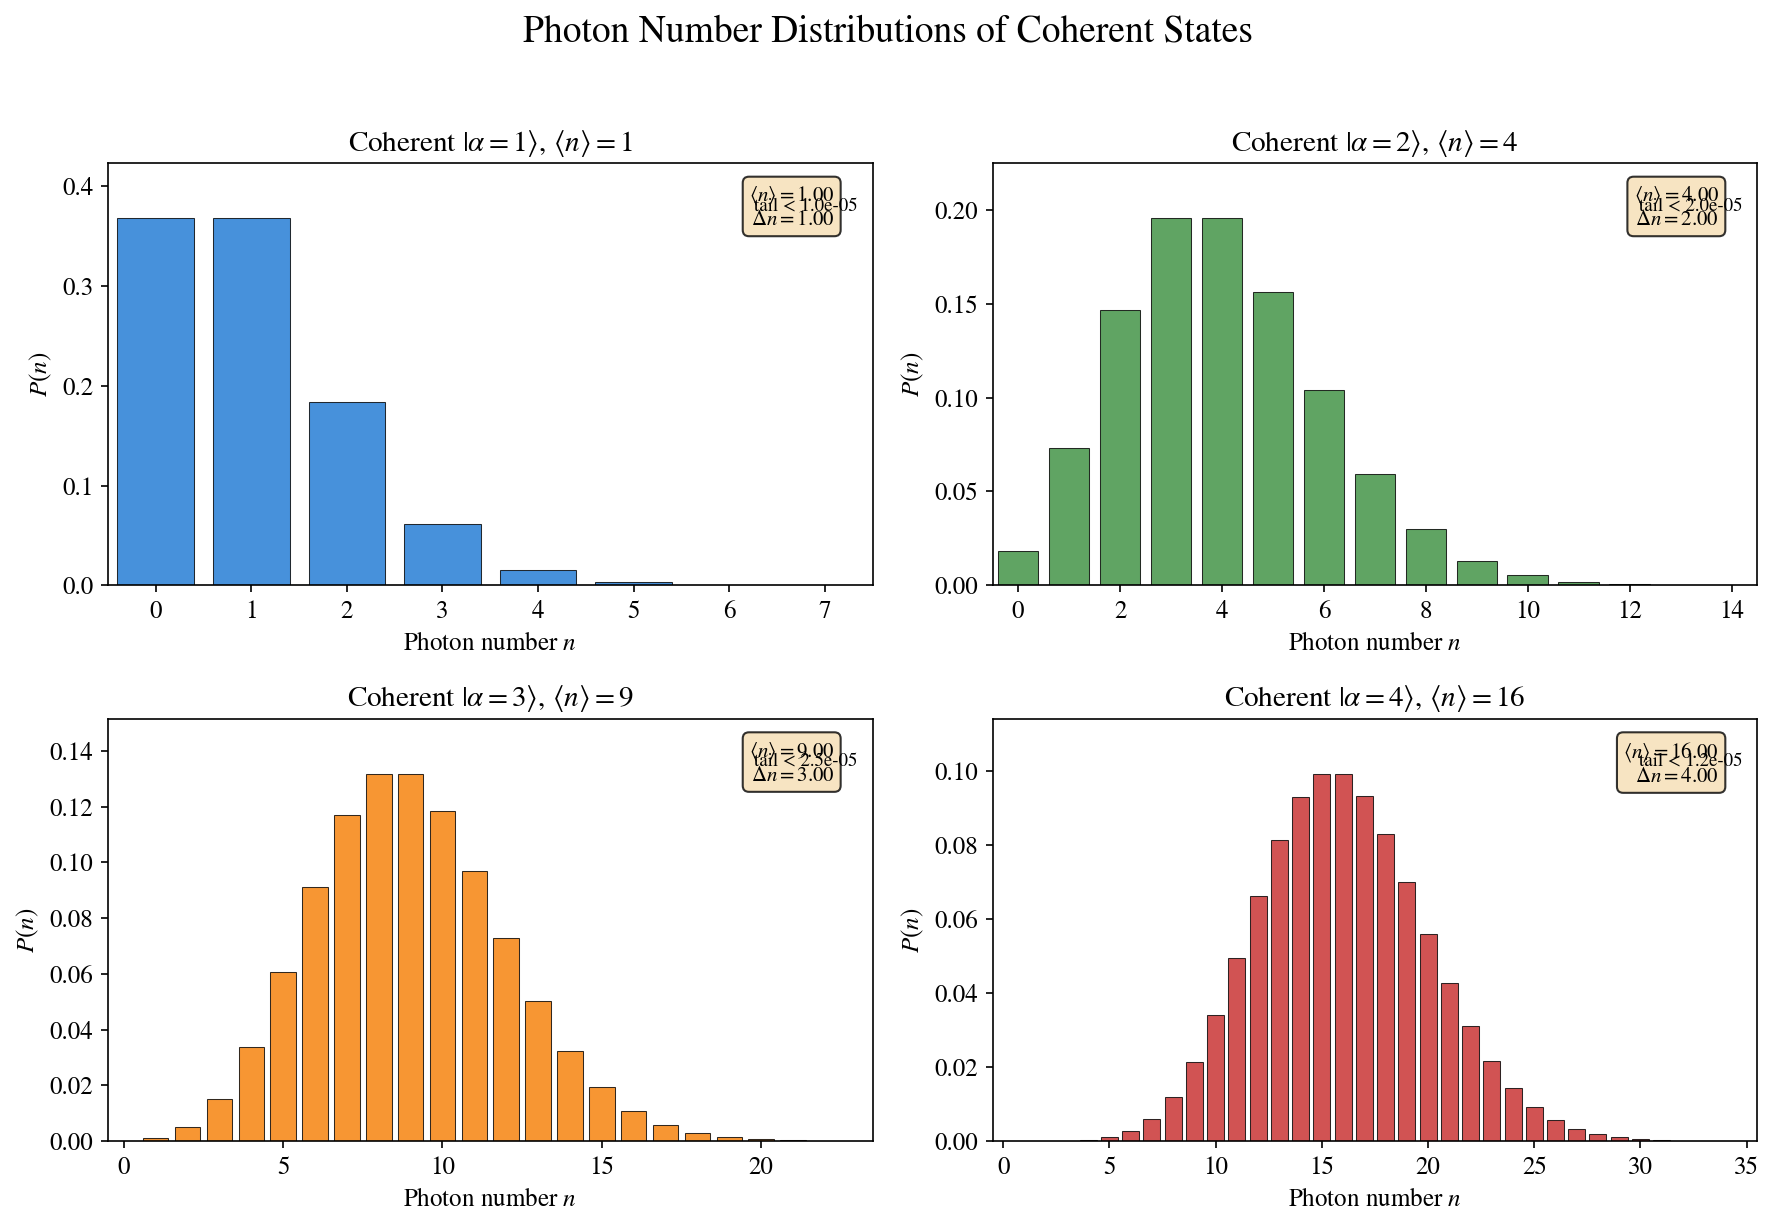

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ['#1976D2', '#388E3C', '#F57C00', '#C62828']

for idx, (alpha, color) in enumerate(zip(alphas, colors)):
    ax = axes[idx // 2, idx % 2]
    state = coherent_states[alpha]
    n_plot = cutoff_from_tail(
        lambda cutoff, alpha=alpha: coherent_tail(cutoff, alpha),
        tolerance=1e-3,
        start=int(alpha**2 + 5*np.sqrt(alpha**2 + 1)),
    )
    tail_omitted = coherent_tail(n_plot, alpha)
    plot_photon_distribution(state, n_max=n_plot,
                             title=rf'Coherent $|\alpha={alpha:.0f}\rangle$, '
                                   rf'$\langle n \rangle = {alpha**2:.0f}$',
                             ax=ax, color=color, show_stats=True)
    ax.text(0.98, 0.92, f"tail < {tail_omitted:.1e}",
            transform=ax.transAxes, ha='right', va='top', fontsize=9)

plt.suptitle('Photon Number Distributions of Coherent States', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'coherent_photon_distributions.png', bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'coherent_photon_distributions.svg', bbox_inches='tight')
plt.show()

## Verifying Poissonian Statistics

To confirm our coherent states have Poisson statistics, we overlay the computed
$P(n)$ with the analytical Poisson distribution
$P_{Poisson}(n) = e^{-\lambda}\lambda^n/n!$ where $\lambda = |\alpha|^2$.

Implementation note: QuTiP constructs coherent states in a finite Hilbert
space. Treat the Poisson overlay as a convergence check: increase `N` if the
residual or analytic tail is not small, and record whether the installed QuTiP
version exposes an explicit analytic construction option.

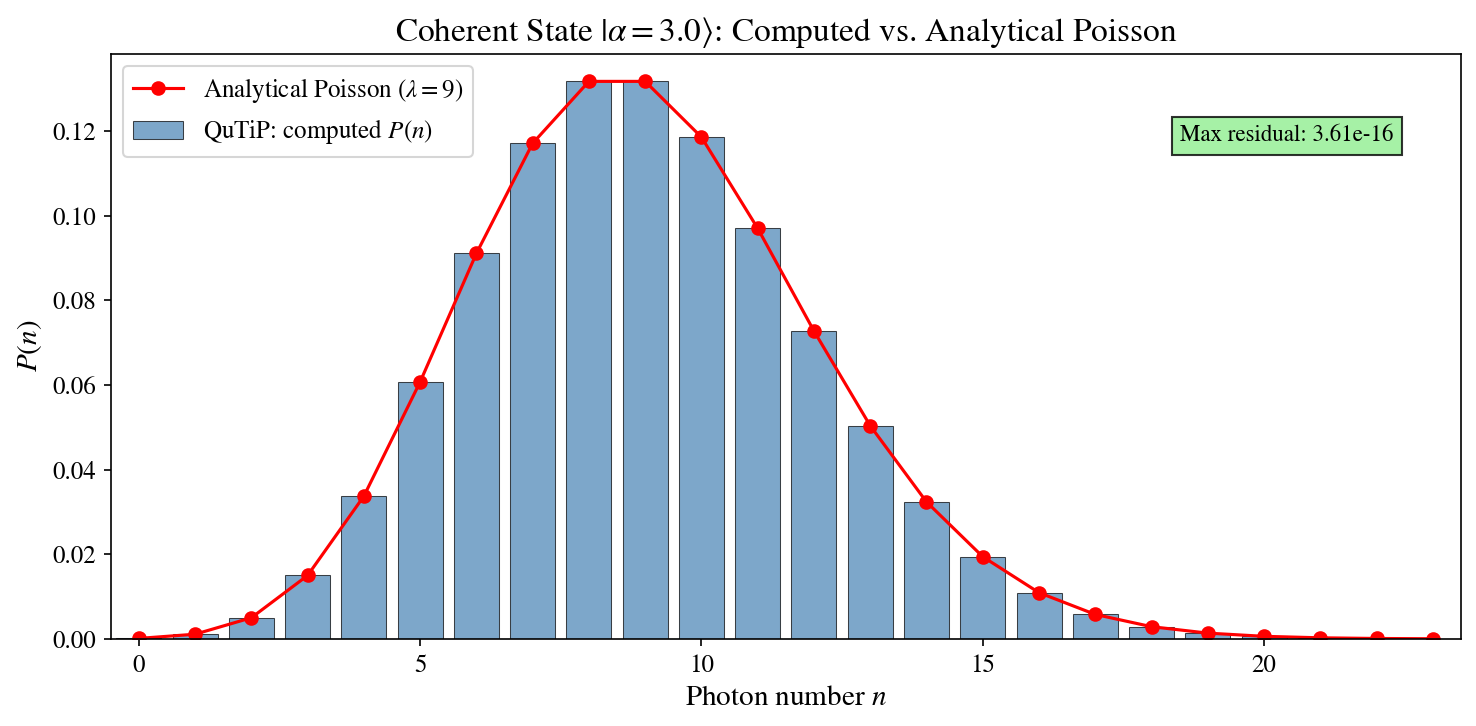

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

alpha = 3.0
state = qutip.coherent(N, alpha)
n_plot = cutoff_from_tail(
    lambda cutoff: coherent_tail(cutoff, alpha),
    tolerance=1e-4,
    start=int(alpha**2 + 5*np.sqrt(alpha**2 + 1)),
)
P_computed = photon_distribution(state, n_max=n_plot)
n_vals = np.arange(n_plot)
assert n_plot > 0, "n_plot must include at least one photon-number bin"

# Computed distribution (bars)
ax.bar(n_vals, P_computed, color='steelblue', alpha=0.7,
       label='QuTiP: computed $P(n)$', edgecolor='black', linewidth=0.5)

# Analytical Poisson (dots connected by line)
lam = alpha**2
P_poisson = np.array([
    np.exp(-lam) * lam**int(n) / math.factorial(int(n))
    for n in n_vals
])
assert len(P_poisson) == len(n_vals) == len(P_computed)
ax.plot(n_vals, P_poisson, 'ro-', markersize=6, linewidth=1.5,
        label=f'Analytical Poisson ($\\lambda = {lam:.0f}$)')

ax.set_xlabel(r'Photon number $n$', fontsize=14)
ax.set_ylabel(r'$P(n)$', fontsize=14)
ax.set_title(rf'Coherent State $|\alpha = {alpha}\rangle$: '
             r'Computed vs. Analytical Poisson', fontsize=16)
ax.legend(fontsize=12)
ax.set_xlim(-0.5, n_plot - 0.5)

# Annotate agreement
compare_bins = min(20, len(P_computed))
assert compare_bins > 0, "Cannot compute residual with zero plotted bins"
residual = np.max(np.abs(P_computed[:compare_bins] - P_poisson[:compare_bins]))
ax.text(0.95, 0.85, f'Max residual: {residual:.2e}',
        transform=ax.transAxes, fontsize=11, ha='right',
        bbox=dict(facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.savefig(FIG_DIR / 'coherent_poisson_overlay.png', bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'coherent_poisson_overlay.svg', bbox_inches='tight')
plt.show()

The bars (QuTiP computation) and dots (analytical Poisson) overlap perfectly,
confirming that `qutip.coherent(N, alpha)` faithfully reproduces the
theoretical Poisson distribution to numerical precision.

## Verifying $g^{(2)}(0) = 1$ for All $\alpha$

For ANY coherent state (regardless of amplitude), $g^{(2)}(0) = 1$ exactly.
This marks the boundary between bunching ($g^{(2)}(0) > 1$, thermal)
and anti-bunching ($g^{(2)}(0) < 1$, Fock).

In [6]:
print("=== g^(2)(0) for Coherent States ===\n")
test_alphas = np.linspace(0.5, 4.0, 8)
for alpha in test_alphas:
    state = qutip.coherent(N, alpha)
    g2 = compute_g2_zero(state, a)
    deviation = abs(g2 - 1.0)
    print(f"alpha = {alpha:>4.1f}  |  g2(0) = {g2:.8f}  |  deviation from 1: {deviation:.2e}")

=== g^(2)(0) for Coherent States ===

alpha =  0.5  |  g2(0) = 1.00000000  |  deviation from 1: 2.22e-16
alpha =  1.0  |  g2(0) = 1.00000000  |  deviation from 1: 0.00e+00
alpha =  1.5  |  g2(0) = 1.00000000  |  deviation from 1: 2.22e-16
alpha =  2.0  |  g2(0) = 1.00000000  |  deviation from 1: 6.66e-16
alpha =  2.5  |  g2(0) = 1.00000000  |  deviation from 1: 1.11e-15
alpha =  3.0  |  g2(0) = 1.00000000  |  deviation from 1: 1.79e-14
alpha =  3.5  |  g2(0) = 1.00000000  |  deviation from 1: 1.19e-10
alpha =  4.0  |  g2(0) = 0.99999991  |  deviation from 1: 9.12e-08


All $g^{(2)}(0)$ values are 1.0 to within numerical precision, confirming
that coherent states sit exactly at the Poissonian boundary.

## Wigner Functions in Phase Space

The Wigner function of a coherent state $|\alpha\rangle$ is a 2D Gaussian:
$$W(x, p) = \frac{1}{\pi} \exp\left[-(x - \sqrt{2}\text{Re}\,\alpha)^2
- (p - \sqrt{2}\text{Im}\,\alpha)^2\right]$$

The center moves to $(\sqrt{2}\,\text{Re}\,\alpha, \sqrt{2}\,\text{Im}\,\alpha)$
while the shape stays circular — minimum uncertainty is preserved.

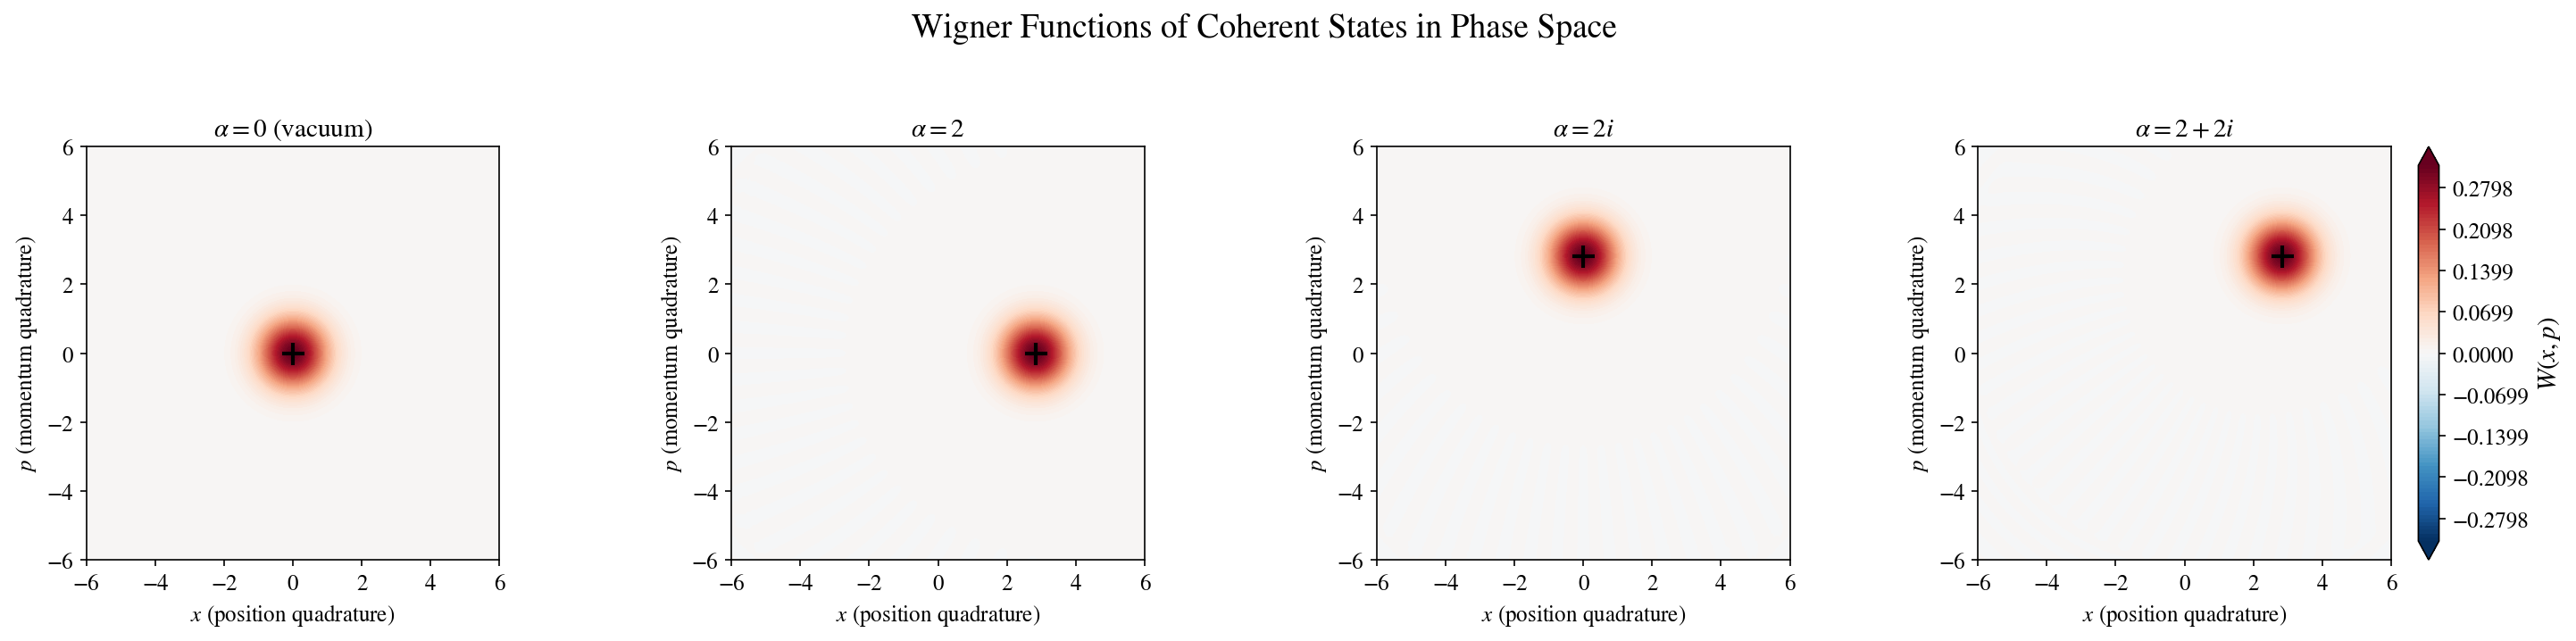

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
wigner_alphas = [0, 2.0, 2.0j, 2+2j]
wigner_labels = [r'$\alpha = 0$ (vacuum)', r'$\alpha = 2$',
                 r'$\alpha = 2i$', r'$\alpha = 2+2i$']
xvec = np.linspace(-6, 6, 200)

for idx, (alpha, label) in enumerate(zip(wigner_alphas, wigner_labels)):
    state = qutip.coherent(N, alpha)
    ax, W = plot_wigner(state, xvec=xvec, title=label, ax=axes[idx],
                         show_colorbar=(idx == 3))
    norm = wigner_normalization(W, xvec, xvec)
    assert np.isclose(norm, 1.0, atol=5e-3), f"Wigner integral for {label} = {norm}"

    # Mark expected center
    axes[idx].plot(np.sqrt(2)*np.real(alpha), np.sqrt(2)*np.imag(alpha),
                   'k+', markersize=12, markeredgewidth=2)

plt.suptitle('Wigner Functions of Coherent States in Phase Space',
             fontsize=18, y=1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'coherent_wigner_phase_space.png', bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'coherent_wigner_phase_space.svg', bbox_inches='tight')
plt.show()

All four Wigner functions are identical positive Gaussian blobs positioned at
different phase-space locations. The cross markers sit at the predicted centers.
No negative regions are visible — coherent states have fully positive Wigner functions.

## Phase-Space Animation: Sweeping $\alpha$

As $\alpha$ increases along the real axis, the Wigner function moves to the right
in phase space while maintaining its circular Gaussian shape.

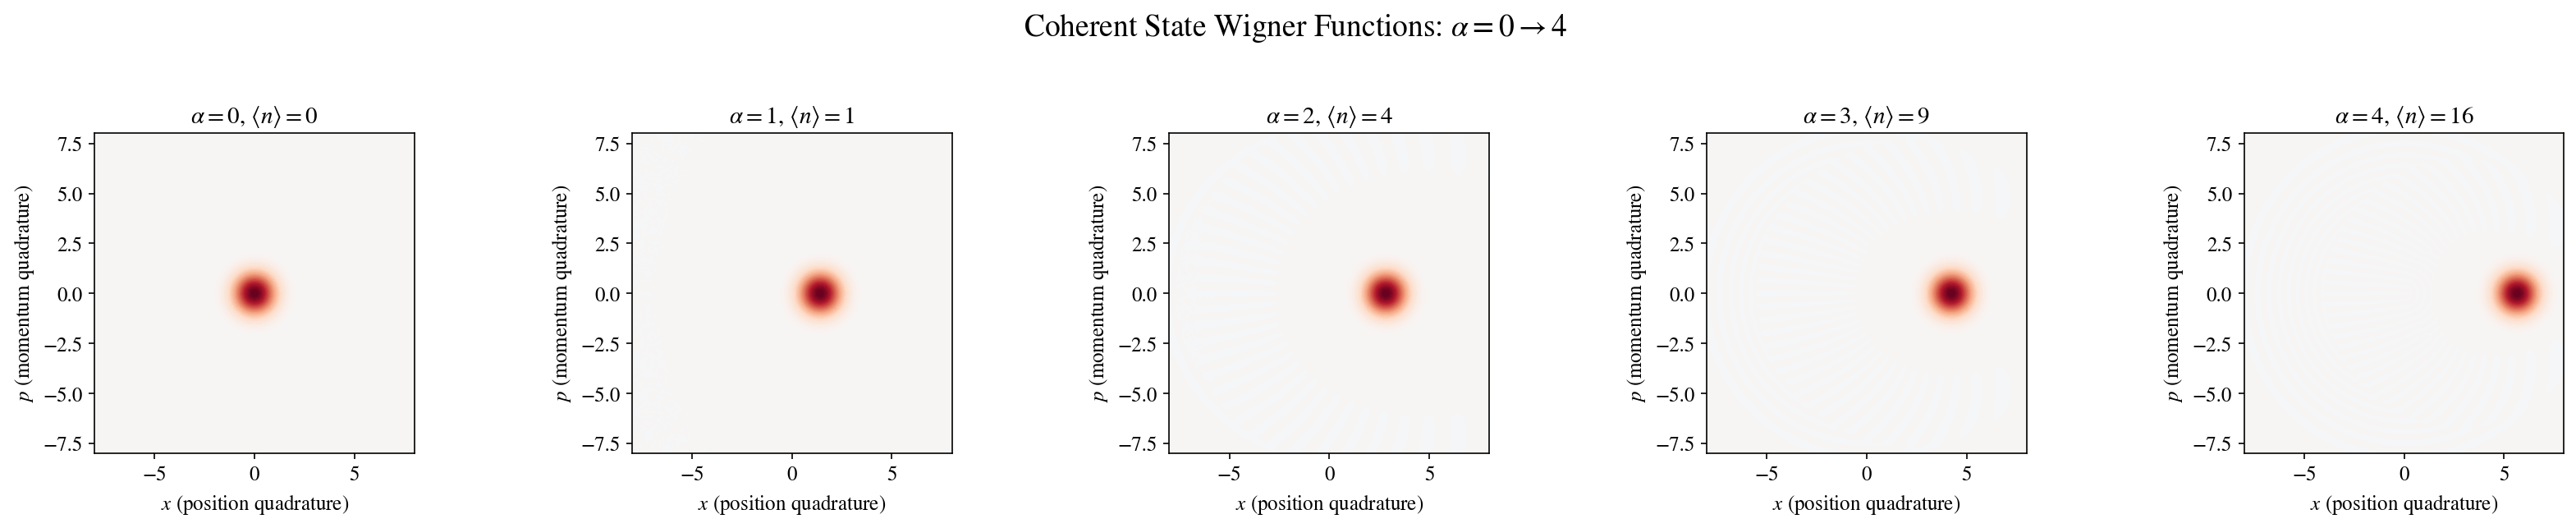

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
sweep_alphas = [0, 1, 2, 3, 4]
xvec = np.linspace(-8, 8, 200)

for idx, alpha in enumerate(sweep_alphas):
    state = qutip.coherent(N, alpha)
    ax, W = plot_wigner(state, xvec=xvec,
                         title=rf'$\alpha = {alpha}$, $\langle n \rangle = {alpha**2}$',
                         ax=axes[idx], show_colorbar=False)
    norm = wigner_normalization(W, xvec, xvec)
    assert np.isclose(norm, 1.0, atol=5e-3), f"Wigner integral for alpha={alpha} = {norm}"

plt.suptitle(r'Coherent State Wigner Functions: $\alpha = 0 \to 4$',
             fontsize=18, y=1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'coherent_wigner_sweep.png', bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'coherent_wigner_sweep.svg', bbox_inches='tight')
plt.show()

## Key Comparison: Fock State vs. Coherent State

This is the central comparison of quantum optics. Both states can have the same
mean photon number, but their statistics are completely different:

| Property | Fock $|3\rangle$ | Coherent $|\alpha=\sqrt{3}\rangle$ |
|----------|-----------------|----------------------------------|
| $\langle n \rangle$ | 3 | 3 |
| $\Delta n$ | 0 | $\sqrt{3} \approx 1.73$ |
| $g^{(2)}(0)$ | 0.667 | 1.0 |
| Mandel $Q$ | -1 | 0 |
| Wigner | Rings with negativity | Positive Gaussian |

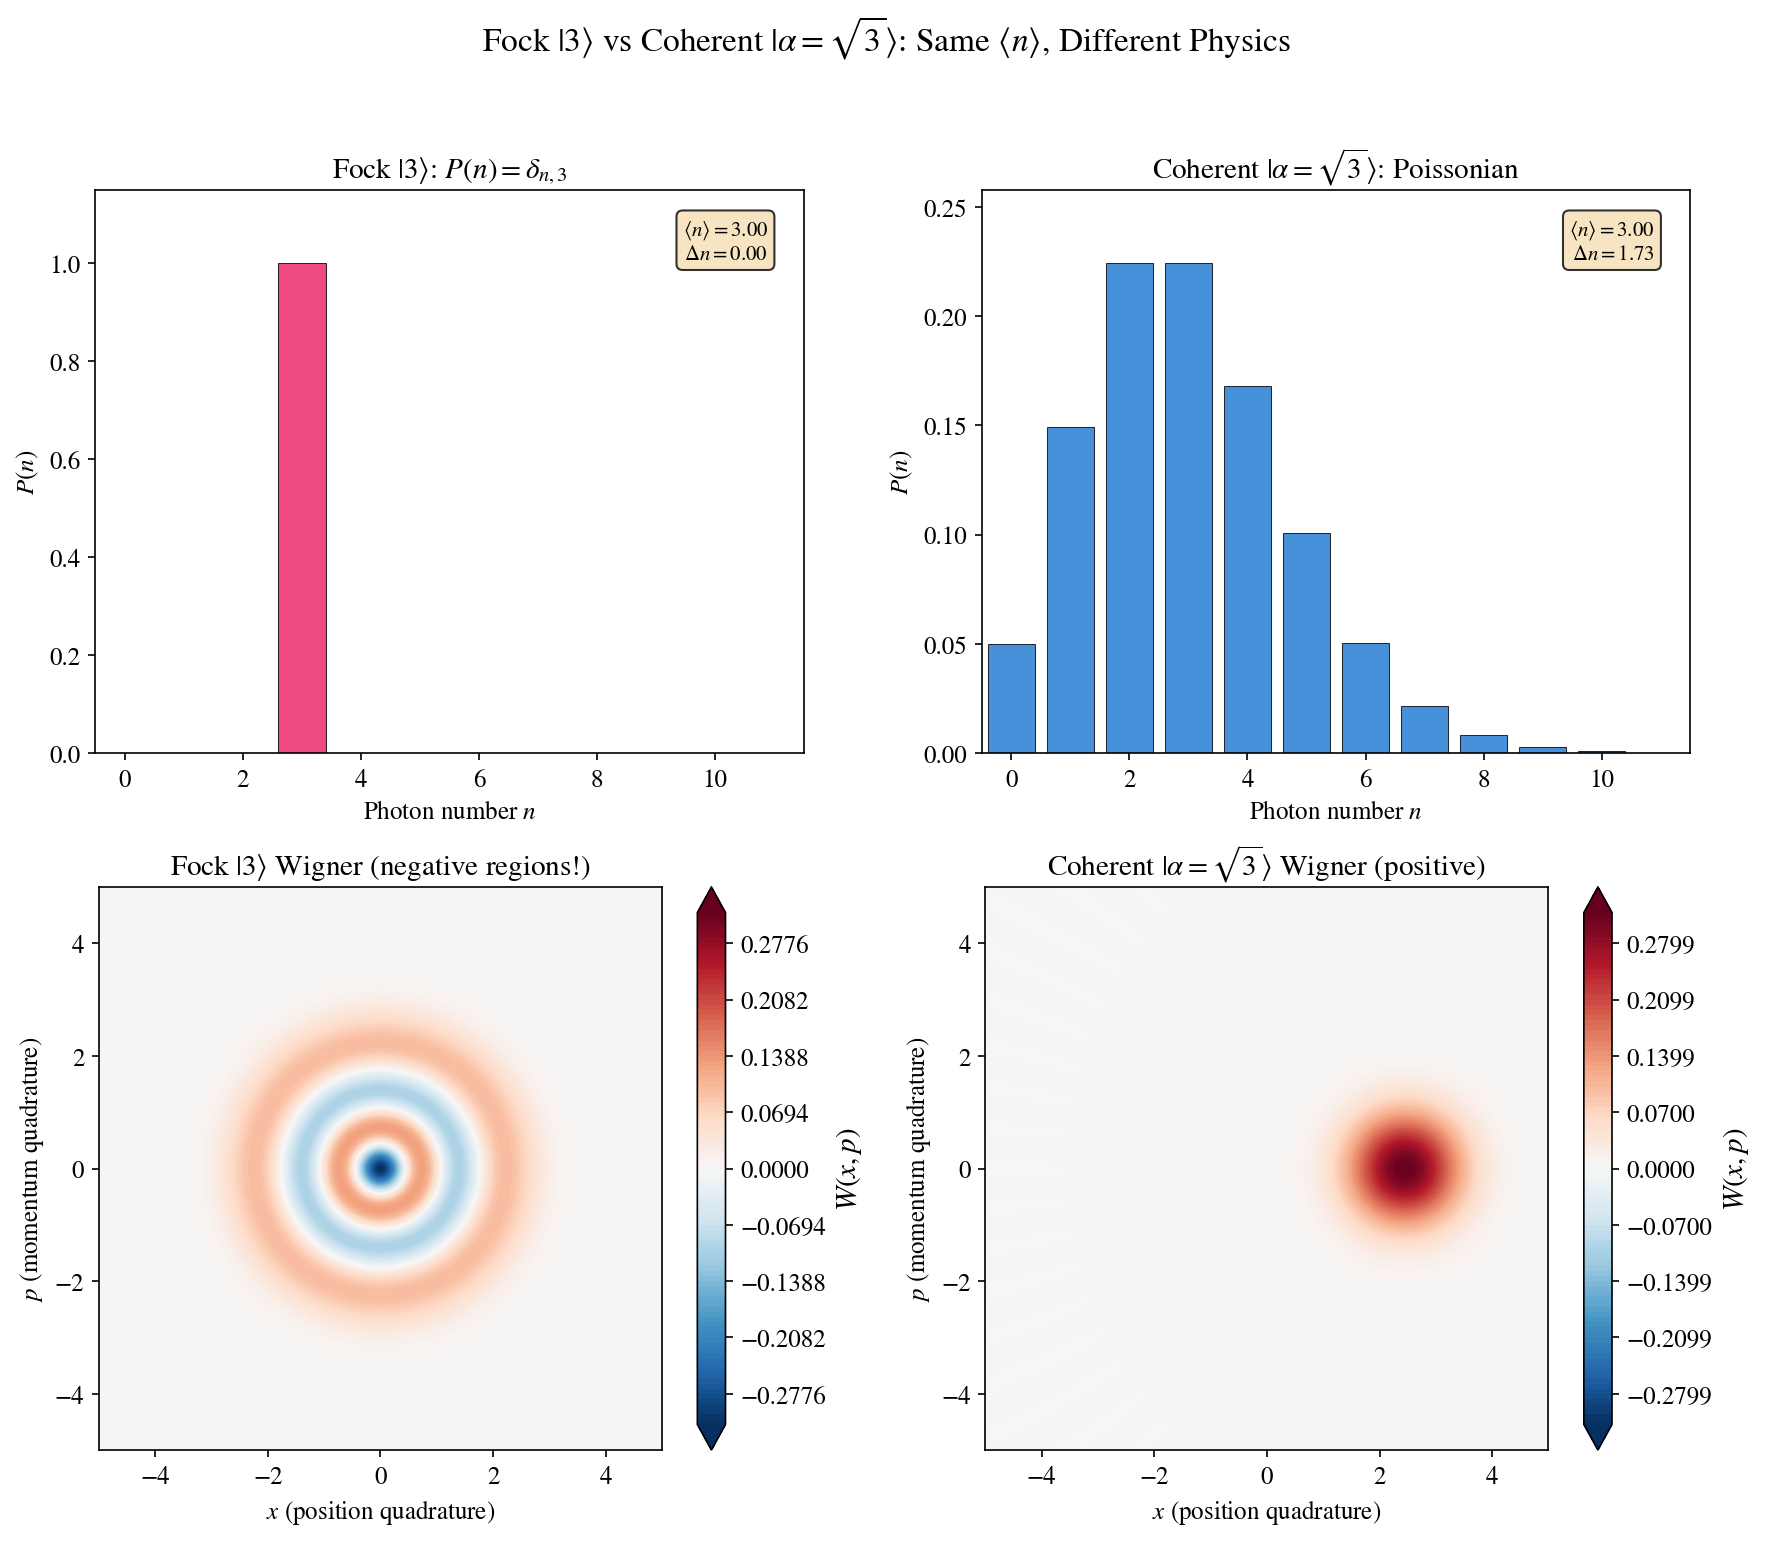


=== Fock vs Coherent Comparison ===
Property               Fock |3> Coherent |sqrt3>
-----------------------------------------------
<n>                       3.000           3.000
Dn                        0.000           1.732
g2(0)                    0.6667          1.0000
Mandel Q                -1.0000          0.0000


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Same mean photon number for fair comparison
n_mean = 3
fock_state = qutip.basis(N, n_mean)
coherent_state = qutip.coherent(N, np.sqrt(n_mean))

# Top left: Fock P(n)
plot_photon_distribution(fock_state, n_max=12,
                         title=rf'Fock $|{n_mean}\rangle$: $P(n) = \delta_{{n,{n_mean}}}$',
                         ax=axes[0, 0], color='#E91E63', show_stats=True)

# Top right: Coherent P(n)
plot_photon_distribution(coherent_state, n_max=12,
                         title=rf'Coherent $|\alpha=\sqrt{{{n_mean}}}\rangle$: Poissonian',
                         ax=axes[0, 1], color='#1976D2', show_stats=True)

# Bottom left: Fock Wigner
xvec = np.linspace(-5, 5, 200)
_, W_fock = plot_wigner(fock_state, xvec=xvec,
                        title=rf'Fock $|{n_mean}\rangle$ Wigner (negative regions!)',
                        ax=axes[1, 0])
assert np.isclose(wigner_normalization(W_fock, xvec, xvec), 1.0, atol=5e-3)

# Bottom right: Coherent Wigner
_, W_coh = plot_wigner(coherent_state, xvec=xvec,
                       title=rf'Coherent $|\alpha=\sqrt{{{n_mean}}}\rangle$ Wigner (positive)',
                       ax=axes[1, 1])
assert np.isclose(wigner_normalization(W_coh, xvec, xvec), 1.0, atol=5e-3)

plt.suptitle(rf'Fock $|{n_mean}\rangle$ vs Coherent $|\alpha=\sqrt{{{n_mean}}}\rangle$: '
             r'Same $\langle n \rangle$, Different Physics',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fock_vs_coherent_comparison.png', bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'fock_vs_coherent_comparison.svg', bbox_inches='tight')
plt.show()

# Print comparison table
print("\n=== Fock vs Coherent Comparison ===")
print(f"{'Property':<15} {'Fock |3>':>15} {'Coherent |sqrt3>':>15}")
print("-" * 47)
print(f"{'<n>':<15} {mean_photon_number(fock_state, a):>15.3f} "
      f"{mean_photon_number(coherent_state, a):>15.3f}")
print(f"{'Dn':<15} {np.sqrt(photon_variance(fock_state, a)):>15.3f} "
      f"{np.sqrt(photon_variance(coherent_state, a)):>15.3f}")
print(f"{'g2(0)':<15} {compute_g2_zero(fock_state, a):>15.4f} "
      f"{compute_g2_zero(coherent_state, a):>15.4f}")
print(f"{'Mandel Q':<15} {mandel_Q(fock_state, a):>15.4f} "
      f"{mandel_Q(coherent_state, a):>15.4f}")

The comparison makes the quantum-classical distinction vivid:
- **Fock** $|3\rangle$: delta-function P(n), rings with Wigner negativity, $g^{(2)}(0) = 0.667$
- **Coherent** $|\alpha=\sqrt{3}\rangle$: Poissonian P(n), positive Gaussian Wigner, $g^{(2)}(0) = 1.0$

Both have $\langle n \rangle = 3$, but their photon statistics and phase-space
structure are fundamentally different.

## In the lab

Coherent states are the quantum-optical model of ideal laser light. Real lasers
are not perfect single-mode coherent states in every detail, but the coherent
state captures the key physics: stable phase, Poissonian photon-number
statistics, and minimum quadrature uncertainty.

## Operator structure

The displacement operator $\hat{D}(\alpha)$ is a Heisenberg-Weyl group element
acting on bosonic Fock space. It shifts the phase-space center of the vacuum
state while preserving minimum uncertainty.


## What this notebook demonstrates

1. **Coherent states** $|\alpha\rangle = \hat{D}(\alpha)|0\rangle$ describe laser light
2. **Poissonian statistics**: $P(n)$ is a Poisson distribution with $\langle n \rangle = |\alpha|^2$
3. **$g^{(2)}(0) = 1$**: the boundary between bunching and anti-bunching
4. **Minimum uncertainty**: $\Delta X \cdot \Delta P = 1/2$ — most classical quantum state
5. **vs. Fock states**: Same $\langle n \rangle$ but different statistics, Wigner functions, and classical-limit behavior